# Phase 6B: Correctness-Predictive Probing

## Why Phase 6 Failed

Phase 6 probed for structural features of the target regex (has_alternation,
has_negation, etc.). These were **lexically predictable** from individual input
tokens: "or" → `|`, "not" → `~`. Layer 0 embeddings hit 0.82–1.0 AUROC, both
models saturated at 1.0 by layer 3, and there was nothing left to compare.

## Better Probe Target

**Did the model produce the exact-match correct regex for this example?**

This is not lexically predictable — you can't tell from the input words whether
the model will get the regex right. It's directly tied to the performance gap
(NTP 25% vs STP 69%), and the per-example labels are already in `eval_output.jsonl`.

## Three Probing Scenarios

1. **NTP model → `ntp_correct`**: At which layer can NTP predict its own success?
2. **STP model → `stp_correct`**: At which layer can STP predict its own success?
3. **Both models → `stp_only`** (STP correct AND NTP incorrect): The ~44% of examples
   where STP's advantage actually manifests. Same label, different activations —
   the sharpest comparison we can make.

In [1]:
from phase6b_probing import (
    load_correctness_labels,
    make_label_sets,
    collect_probe_activations_eval,
    run_correctness_sweep,
    plot_correctness_curves,
    print_correctness_report,
    PROBE_LAYERS,
)
from phase6_probing import paired_bootstrap_delta
from phase4b_subspace import load_chat_texts
from transformers import AutoTokenizer
import pandas as pd
import numpy as np

MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
EVAL_FILE = "../datasets/synth_test.jsonl"
NTP_EVAL  = "/home/jay/repos/llm-jepa/output-exp1-regular/eval_output.jsonl"
STP_EVAL  = "/home/jay/repos/llm-jepa/output-exp1-stp/eval_output.jsonl"
LAYERS    = PROBE_LAYERS  # [0, 3, 7, 11, 15]
BATCH_SIZE = 8
SEQ_LEN   = 128

## Load Correctness Labels

In [2]:
ntp_correct = load_correctness_labels(NTP_EVAL)
stp_correct = load_correctness_labels(STP_EVAL)
labels_dict = make_label_sets(ntp_correct, stp_correct)


Label Summary (n=2000)
-------------------------------------------------------
  Label                     Pos    Neg    Rate
-------------------------------------------------------
  ntp_correct               503   1497   0.252
  stp_correct              1385    615   0.693
  stp_only                  892   1108   0.446
-------------------------------------------------------
  Both correct:            493  (0.246)
  Neither correct:         605  (0.302)


## Load Eval Texts

Same 2000 examples as were evaluated, in the same order as eval_output.jsonl.
Chat template applied so inputs match what the model saw.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
tokenizer.pad_token = tokenizer.eos_token

eval_texts, _ = load_chat_texts(EVAL_FILE, tokenizer)
print(f"Eval examples: {len(eval_texts)}")
assert len(eval_texts) == len(ntp_correct), "Mismatch between texts and labels"

Eval examples: 2000


## Collect Activations

Single forward pass per batch extracts all 5 layers simultaneously.
Probe position: `\n\n` token immediately before regex generation
(second `<|eot_id|>` + 4 in the tokenized sequence).

In [4]:
print("=== NTP ===")
ntp_acts = collect_probe_activations_eval(
    MODELS["NTP"], eval_texts, layers=LAYERS,
    batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
)

=== NTP ===
  Loading model from /home/jay/repos/llm-jepa/output-exp1-regular
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Layer  0: (2000, 2048)
  Layer  3: (2000, 2048)
  Layer  7: (2000, 2048)
  Layer 11: (2000, 2048)
  Layer 15: (2000, 2048)


In [7]:
print("=== STP ===")
stp_acts = collect_probe_activations_eval(
    MODELS["STP"], eval_texts, layers=LAYERS,
    batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
)

=== STP ===
  Loading model from /home/jay/repos/llm-jepa/output-exp1-stp
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Layer  0: (2000, 2048)
  Layer  3: (2000, 2048)
  Layer  7: (2000, 2048)
  Layer 11: (2000, 2048)
  Layer 15: (2000, 2048)


## Run Probes

75/25 stratified split. Same split indices used across all layers for a given label
(so layer-to-layer comparisons are valid). Scenario 3 uses the same test indices for
NTP and STP (enabling paired bootstrap).

In [5]:
print("=== NTP probes ===")
ntp_results, ntp_splits = run_correctness_sweep(
    ntp_acts, labels_dict,
    label_keys=["ntp_correct", "stp_only"],
    layers=LAYERS,
)

=== NTP probes ===
  layer= 0  ntp_correct             AUROC=0.650  bal_acc=0.625
  layer= 0  stp_only                AUROC=0.581  bal_acc=0.582
  layer= 3  ntp_correct             AUROC=0.734  bal_acc=0.644
  layer= 3  stp_only                AUROC=0.725  bal_acc=0.681
  layer= 7  ntp_correct             AUROC=0.784  bal_acc=0.688
  layer= 7  stp_only                AUROC=0.768  bal_acc=0.719
  layer=11  ntp_correct             AUROC=0.819  bal_acc=0.757
  layer=11  stp_only                AUROC=0.781  bal_acc=0.712
  layer=15  ntp_correct             AUROC=0.828  bal_acc=0.752
  layer=15  stp_only                AUROC=0.772  bal_acc=0.699


In [8]:
print("=== STP probes ===")
stp_results, stp_splits = run_correctness_sweep(
    stp_acts, labels_dict,
    label_keys=["stp_correct", "stp_only"],
    layers=LAYERS,
)

=== STP probes ===
  layer= 0  stp_correct             AUROC=0.637  bal_acc=0.587
  layer= 0  stp_only                AUROC=0.579  bal_acc=0.582
  layer= 3  stp_correct             AUROC=0.808  bal_acc=0.706
  layer= 3  stp_only                AUROC=0.727  bal_acc=0.681
  layer= 7  stp_correct             AUROC=0.857  bal_acc=0.783
  layer= 7  stp_only                AUROC=0.765  bal_acc=0.719
  layer=11  stp_correct             AUROC=0.889  bal_acc=0.804
  layer=11  stp_only                AUROC=0.781  bal_acc=0.727
  layer=15  stp_correct             AUROC=0.895  bal_acc=0.841
  layer=15  stp_only                AUROC=0.787  bal_acc=0.715


## Results: Probing Curves

Saved: phase6b_curves.png


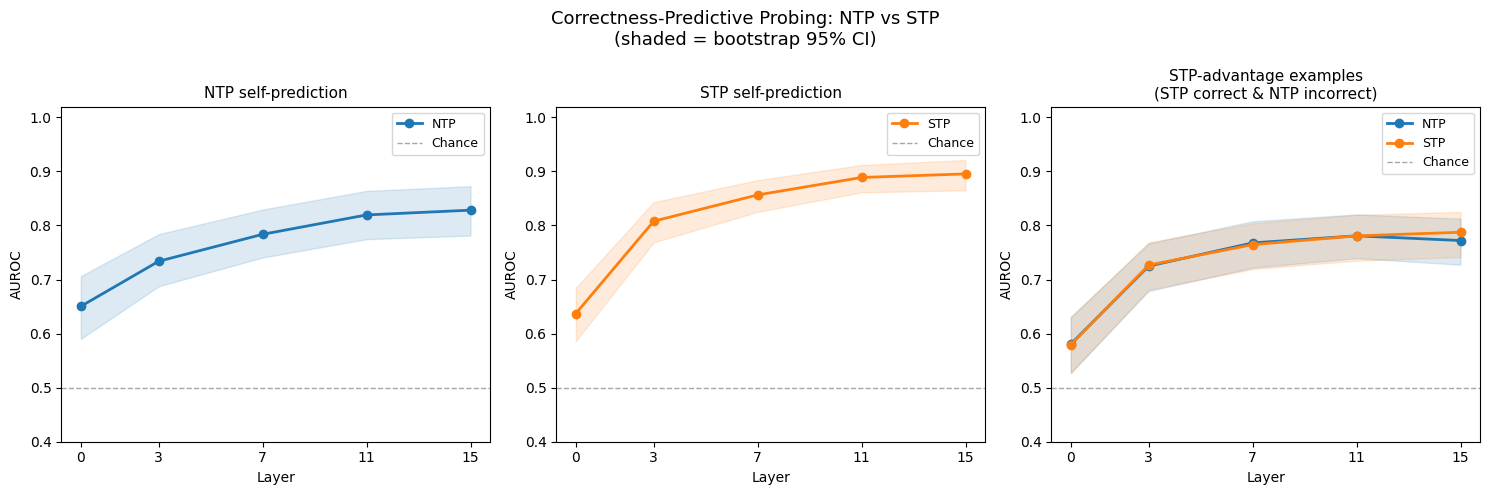

In [9]:
plot_correctness_curves(
    ntp_results, stp_results, labels_dict,
    layers=LAYERS, n_bootstrap=500,
    save_path="phase6b_curves.png",
)

## Statistical Comparison: STP-Only Examples

Paired bootstrap on (STP − NTP) AUROC for the `stp_only` label.
Both models evaluated on the same 500 test examples.

In [10]:
# Compute per-layer paired bootstrap deltas for stp_only
stp_only_deltas = []
y_true_test = labels_dict["stp_only"].astype(int)[ntp_splits["stp_only"][1]]

for layer in LAYERS:
    ntp_row = ntp_results[(ntp_results.layer == layer) & (ntp_results.label == "stp_only")].iloc[0]
    stp_row = stp_results[(stp_results.layer == layer) & (stp_results.label == "stp_only")].iloc[0]

    delta = paired_bootstrap_delta(
        y_true_test, ntp_row["y_prob"], stp_row["y_prob"], n_bootstrap=1000
    )
    stp_only_deltas.append({"layer": layer, **delta})
    sig = " *" if delta["significant"] else ""
    print(f"  Layer {layer:2d}: delta={delta['delta_auroc']:+.3f}  "
          f"95% CI [{delta['ci_low']:+.3f}, {delta['ci_high']:+.3f}]{sig}")

import pandas as pd
deltas_df = pd.DataFrame(stp_only_deltas)

  Layer  0: delta=-0.001  95% CI [-0.003, +0.000]
  Layer  3: delta=+0.002  95% CI [-0.002, +0.006]
  Layer  7: delta=-0.003  95% CI [-0.011, +0.004]
  Layer 11: delta=+0.000  95% CI [-0.013, +0.013]
  Layer 15: delta=+0.015  95% CI [-0.006, +0.038]


In [11]:
print_correctness_report(ntp_results, stp_results, deltas_df)


Correctness Probing Report

  NTP self-prediction (ntp_correct)
    Layer     AUROC   Bal.Acc
  -------  --------  --------
        0     0.650     0.625
        3     0.734     0.644
        7     0.784     0.688
       11     0.819     0.757
       15     0.828     0.752

  STP self-prediction (stp_correct)
    Layer     AUROC   Bal.Acc
  -------  --------  --------
        0     0.637     0.587
        3     0.808     0.706
        7     0.857     0.783
       11     0.889     0.804
       15     0.895     0.841

  STP-advantage examples (stp_only)
    Layer   NTP AUROC   STP AUROC     Delta   Sig
  -------  ----------  ----------  --------  ----
        0       0.581       0.579    -0.001
        3       0.725       0.727    +0.002
        7       0.768       0.765    -0.003
       11       0.781       0.781    -0.000
       15       0.772       0.787    +0.015



intepretation: STP predicts it's own success better than NTP indicating that it's representations are perhaps are better organized for this task.
NTP and STP have the same AUROC on examples where STP succeeds and NTP does not, indicating that the information is present for both, but NTP fails to act on that information in some way. THis tells us the geometric structure between the two is basically the same, the NTP processing is just worse.

## Interpretation

**Layer 0 check**: Both models should be near chance (0.5 AUROC) for correctness labels.
Correctness isn't deducible from individual input tokens. If layer 0 is high, there's
a confound (e.g., short/easy inputs correlate with correctness).

**Self-prediction curves**: Does STP's AUROC rise earlier (commits to correct answer
earlier in the network) or reach a higher ceiling (more certain representations)?

**STP-only comparison** (subplot 3): This is the key. On examples where STP succeeds
but NTP fails, does STP build meaningfully different representations? If STP AUROC > NTP
AUROC with a significant delta, it means STP's representations genuinely differentiate
the hard examples it gets right — a direct mechanistic account of the performance gap.